Disease Risk Prediction 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
df = pd.read_csv("Assign1_ml.csv")
print(df.head())

  Patient ID  Age  Gender Blood_Pressure  Heart Rate  Cholesterol        BMI  \
0    BMW7812   67    Male         158/88          72          208  31.251233   
1    CZE1114   21    Male         165/93          98          389  27.194973   
2    BNI9906   21  Female         174/99          72          324  28.176571   
3    JLN3497   84    Male        163/100          73          383  36.464704   
4    GFO8847   66    Male          91/88          93          318  21.809144   

   Smoking  Exercise_Hours_Per_Week  Triglycerides  \
0        1                 4.168189            286   
1        1                 1.813242            235   
2        0                 2.078353            587   
3        1                 9.828130            378   
4        1                 5.804299            231   

                                 Medical_Report_Text  Heart_Attack_Risk  \
0  Elderly male with stage 1 hypertension, obese ...                  0   
1  Young male with severe hypertension and v

In [4]:
df.shape

(335, 13)

In [5]:
df.describe()

,Age,Heart Rate,Cholesterol,BMI,Smoking,Exercise_Hours_Per_Week,Triglycerides,Heart_Attack_Risk,Treatment_Success_Rate
count,335.000000,335.000000,335.000000,335.000000,335.000000,335.000000,335.000000,335.000000,334.000000
mean,54.426866,76.516418,252.865672,28.736818,0.886567,10.011152,438.683582,0.343284,59.811377
std,21.457935,19.817253,80.926206,6.531940,0.317596,5.822099,223.341435,0.475515,7.584384
min,18.000000,40.000000,120.000000,18.036223,0.000000,0.004443,31.000000,0.000000,35.000000
25%,36.000000,59.000000,192.500000,22.717663,1.000000,4.945660,249.000000,0.000000,55.000000
50%,54.000000,76.000000,246.000000,28.325443,1.000000,9.805251,451.000000,0.000000,60.000000
75%,73.000000,94.000000,324.500000,34.362912,1.000000,15.212586,639.000000,1.000000,65.000000
max,90.000000,110.000000,399.000000,39.997211,1.000000,19.998709,798.000000,1.000000,85.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               335 non-null    object 
 1   Age                      335 non-null    int64  
 2   Gender                   335 non-null    object 
 3   Blood_Pressure           335 non-null    object 
 4   Heart Rate               335 non-null    int64  
 5   Cholesterol              335 non-null    int64  
 6   BMI                      335 non-null    float64
 7   Smoking                  335 non-null    int64  
 8   Exercise_Hours_Per_Week  335 non-null    float64
 9   Triglycerides            335 non-null    int64  
 10  Medical_Report_Text      335 non-null    object 
 11  Heart_Attack_Risk        335 non-null    int64  
 12  Treatment_Success_Rate   334 non-null    float64
dtypes: float64(3), int64(6), object(4)
memory usage: 34.2+ KB


In [7]:
df.columns

Index(['Patient ID', 'Age', 'Gender', 'Blood_Pressure', 'Heart Rate',
       'Cholesterol', 'BMI', 'Smoking', 'Exercise_Hours_Per_Week',
       'Triglycerides', 'Medical_Report_Text', 'Heart_Attack_Risk',
       'Treatment_Success_Rate'],
      dtype='object')

In [8]:
df.dtypes

Patient ID                  object
Age                          int64
Gender                      object
Blood_Pressure              object
Heart Rate                   int64
Cholesterol                  int64
BMI                        float64
Smoking                      int64
Exercise_Hours_Per_Week    float64
Triglycerides                int64
Medical_Report_Text         object
Heart_Attack_Risk            int64
Treatment_Success_Rate     float64
dtype: object

In [9]:
df.isnull().sum()

Patient ID                 0
Age                        0
Gender                     0
Blood_Pressure             0
Heart Rate                 0
Cholesterol                0
BMI                        0
Smoking                    0
Exercise_Hours_Per_Week    0
Triglycerides              0
Medical_Report_Text        0
Heart_Attack_Risk          0
Treatment_Success_Rate     1
dtype: int64

In [10]:
df=df.dropna()

In [11]:
df.isnull().sum()

Patient ID                 0
Age                        0
Gender                     0
Blood_Pressure             0
Heart Rate                 0
Cholesterol                0
BMI                        0
Smoking                    0
Exercise_Hours_Per_Week    0
Triglycerides              0
Medical_Report_Text        0
Heart_Attack_Risk          0
Treatment_Success_Rate     0
dtype: int64

In [12]:
df['Gender']=df['Gender'].map({'Male' : 0, 'Female' : 1})

In [13]:

df[['Systolic_bp', 'Diastolic_bp']] = df['Blood_Pressure'].str.split('/', expand=True)

In [14]:
df['Systolic_bp'] = pd.to_numeric(df['Systolic_bp'])
df['Diastolic_bp'] = pd.to_numeric(df['Diastolic_bp'])

In [15]:
df.dtypes


Patient ID                  object
Age                          int64
Gender                       int64
Blood_Pressure              object
Heart Rate                   int64
Cholesterol                  int64
BMI                        float64
Smoking                      int64
Exercise_Hours_Per_Week    float64
Triglycerides                int64
Medical_Report_Text         object
Heart_Attack_Risk            int64
Treatment_Success_Rate     float64
Systolic_bp                  int64
Diastolic_bp                 int64
dtype: object

In [16]:
df1=df.copy()

In [17]:
def label_condition(text):
    text.lower()
    if any(word in text for word in ['severe hypertension', 'stage 2 hypertension', 'uncontrolled hypertension',
                                     'chest pain', 'chest tightness', 'angina', 'Very active smoker'
                                     'very high cholesterol/triglycerides', 'high cardiovascular risk', 
                                     'high risk category', 'high , intervention needed', 'Alarming'
                                     'requires pacing evaluation', 'elevated heart rate' ]):
        return 'Severe Condition'
    elif any(word in text for word in ['Controlled BP', 'borderline BP', 'pre-hypertension', 'asymptomatic', 'moderate risk',
                                        'low current risk', 'Active lifestyle', 'without severe symptoms',
                                        'Normal BMI', 'normal lipids', 'moderate activity',
                                         'Good Activity', 'Stage 1 hypertension', 'bp control', 'Good capacity',
                                         'Normal cholesterol', 'non smoker', 'normal weight', 'normal', 'active', 'management']):
        return 'Mild Condition'
    else:
        return 'Moderate Codition'

In [18]:
df1['Condition_Category']=df1['Medical_Report_Text'].apply(label_condition)

In [19]:
df1['Condition_Category'].value_counts()

Condition_Category
Mild Condition       126
Severe Condition     107
Moderate Codition    101
Name: count, dtype: int64

In [20]:
df1[['Medical_Report_Text', 'Condition_Category']].head(10)

,Medical_Report_Text,Condition_Category
0,"Elderly male with stage 1 hypertension, obese ...",Moderate Codition
1,Young male with severe hypertension and very h...,Severe Condition
2,"Young female with stage 2 hypertension, very h...",Severe Condition
3,"Elderly male with uncontrolled hypertension, h...",Severe Condition
4,"Controlled blood pressure, normal BMI but high...",Mild Condition
5,"Middle-aged female with hypertension, very hig...",Severe Condition
6,"Very elderly male with high cholesterol, overw...",Moderate Codition
7,"Elderly male with borderline BP, elevated hear...",Severe Condition
8,"Young male with severe hypertension, obese, ve...",Severe Condition
9,"Middle-aged female with hypertension, sedentar...",Mild Condition


In [21]:
def risk_category(row):
    if row['Heart_Attack_Risk'] == 1 and row['Age'] > 65 and (row['Systolic_bp'] > 150 or row['Cholesterol'] > 350 or row['BMI'] > 30)\
    or row['Smoking'] == 1 and row['Treatment_Success_Rate'] < 60:
        return 'High'
    elif (row['Systolic_bp'] >=135 or row['Cholesterol'] > 300 or row['BMI'] < 20)\
        and row['Treatment_Success_Rate'] < 70  :
        return 'Medium'
    else:
        return 'Low'

In [22]:
df['Risk_category'] = df.apply(risk_category, axis=1)

In [23]:
df['Risk_category'].value_counts()

Risk_category
High      157
Medium     95
Low        82
Name: count, dtype: int64

In [24]:
df['Risk_category'].head(10)

0      High
1    Medium
2    Medium
3      High
4       Low
5      High
6      High
7      High
8    Medium
9    Medium
Name: Risk_category, dtype: object

In [25]:
li_x=df[['Systolic_bp','Diastolic_bp', 'Cholesterol', 'BMI', 'Triglycerides','Exercise_Hours_Per_Week']]
li_y=df['Treatment_Success_Rate']

In [26]:
lo_x=df[['Systolic_bp', 'Diastolic_bp', 'Cholesterol', 'BMI', 'Triglycerides', 'Smoking', 'Age', 'Heart Rate']]
lo_y=df['Heart_Attack_Risk']

In [27]:
nb_x=df1['Medical_Report_Text']
nb_y=df1['Condition_Category']

In [28]:
svm_x=df[['Systolic_bp', 'Diastolic_bp', 'Heart Rate', 'Cholesterol', 'BMI', 'Smoking', 'Exercise_Hours_Per_Week',
      'Treatment_Success_Rate']]
svm_y=df['Risk_category']

In [29]:
li_x_train, li_x_test, li_y_train, li_y_test = train_test_split(li_x, li_y, test_size=0.2, random_state=42)

In [30]:
lo_x_train, lo_x_test, lo_y_train, lo_y_test = train_test_split(lo_x, lo_y, test_size=0.2, random_state=42)

In [31]:
nb_x_train, nb_x_test, nb_y_train, nb_y_test= train_test_split(nb_x, nb_y, test_size=0.2, random_state=42, stratify=nb_y)

In [32]:
svm_x_train, svm_x_test, svm_y_train, svm_y_test= train_test_split(svm_x, svm_y, test_size=0.2, random_state=42)

In [33]:
scaler = StandardScaler()
li_x_train = scaler.fit_transform(li_x_train)
li_x_test = scaler.transform(li_x_test)

In [34]:
scaler = StandardScaler()
lo_x_train = scaler.fit_transform(lo_x_train)
lo_x_test = scaler.transform(lo_x_test)

In [35]:
vectorizer= TfidfVectorizer(stop_words='english', max_features=1000)
nb_x_train_tfidf=vectorizer.fit_transform(nb_x_train)
nb_x_test_tfidf=vectorizer.transform(nb_x_test)

In [36]:
scaler = StandardScaler()
svm_x_train = scaler.fit_transform(svm_x_train)
svm_x_test = scaler.transform(svm_x_test)

In [37]:
li_model=LinearRegression()
li_model.fit(li_x_train, li_y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
lo_model=LogisticRegression()
lo_model.fit(lo_x_train, lo_y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
nb_model=MultinomialNB()
nb_model.fit(nb_x_train_tfidf, nb_y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [40]:
svm_model = SVC(kernel='linear', C=1, gamma='scale')
svm_model.fit(svm_x_train, svm_y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
li_y_pred = li_model.predict(li_x_test)

In [42]:
lo_y_pred = lo_model.predict(lo_x_test)

In [43]:
nb_y_pred= nb_model.predict(nb_x_test_tfidf)

In [44]:
svm_y_pred = svm_model.predict(svm_x_test)

In [45]:
print("\nLinear Model Performance Metrics ")
r2=r2_score(li_y_test, li_y_pred)
mse=mean_squared_error(li_y_test, li_y_pred)
print(f"r2_score : {r2:.3f}")
print(f"mean_squared_error : {mse:.3f}")
print(f"Accuracy: {r2*100:.3f}")



Linear Model Performance Metrics 
r2_score : 0.009
mean_squared_error : 53.311
Accuracy: 0.913


In [46]:
print("\nLogistic Model Performance Metrics ")
print("Accuracy:", accuracy_score(lo_y_test, lo_y_pred))
print('Classification Report: \n', classification_report(lo_y_test, lo_y_pred))



Logistic Model Performance Metrics 
Accuracy: 0.5671641791044776
Classification Report: 
               precision    recall  f1-score   support

           0       0.61      0.86      0.71        42
           1       0.25      0.08      0.12        25

    accuracy                           0.57        67
   macro avg       0.43      0.47      0.42        67
weighted avg       0.48      0.57      0.49        67



In [47]:
print("\nNaive Bayes Model Performance Metrics ")
print('Model Accuracy', accuracy_score(nb_y_test, nb_y_pred))
print('Classification Report: \n', classification_report(nb_y_test, nb_y_pred))


Naive Bayes Model Performance Metrics 
Model Accuracy 0.7910447761194029
Classification Report: 
                    precision    recall  f1-score   support

   Mild Condition       0.81      0.88      0.85        25
Moderate Codition       0.74      0.70      0.72        20
 Severe Condition       0.81      0.77      0.79        22

         accuracy                           0.79        67
        macro avg       0.79      0.78      0.78        67
     weighted avg       0.79      0.79      0.79        67



In [48]:
print("\nSVM Model Performance Metrics ")
print("Accuracy:", accuracy_score(svm_y_test, svm_y_pred))
print(classification_report(svm_y_test, svm_y_pred))


SVM Model Performance Metrics 
Accuracy: 0.8805970149253731
              precision    recall  f1-score   support

        High       0.89      1.00      0.94        34
         Low       0.92      0.69      0.79        16
      Medium       0.82      0.82      0.82        17

    accuracy                           0.88        67
   macro avg       0.88      0.84      0.85        67
weighted avg       0.88      0.88      0.88        67



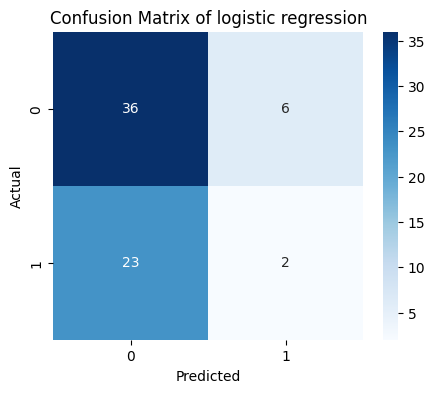

In [49]:
lo_cm = confusion_matrix(lo_y_test, lo_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(lo_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix of logistic regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

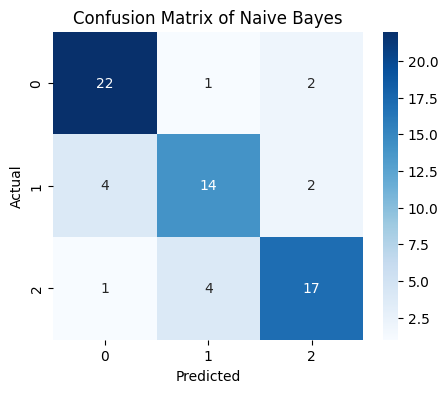

In [50]:
nb_cm = confusion_matrix(nb_y_test, nb_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix of Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

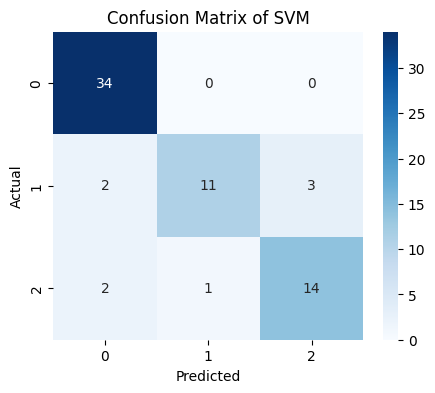

In [51]:
svm_cm = confusion_matrix(svm_y_test, svm_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix of SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [52]:
lo_precision=precision_score(lo_y_test, lo_y_pred, average='macro')
nb_precision=precision_score(nb_y_test, nb_y_pred, average='macro')
svm_precision=precision_score(svm_y_test, svm_y_pred, average='macro')
print(lo_precision, nb_precision, svm_precision)


0.4300847457627119 0.7870602432005941 0.8783109735122118


In [53]:
lo_recall=recall_score(lo_y_test, lo_y_pred, average='macro')
nb_recall=recall_score(nb_y_test, nb_y_pred, average='macro')
svm_recall=recall_score(svm_y_test, svm_y_pred, average='macro')
print(lo_recall, nb_recall, svm_recall)

0.4685714285714285 0.7842424242424242 0.8370098039215685


In [54]:
lo_f1=f1_score(lo_y_test, lo_y_pred, average='macro')
nb_f1=f1_score(nb_y_test, nb_y_pred, average='macro')
svm_f1=f1_score(svm_y_test, svm_y_pred, average='macro')
print(lo_f1, nb_f1, svm_f1)

0.417041704170417 0.7849334128403895 0.8512293806411453


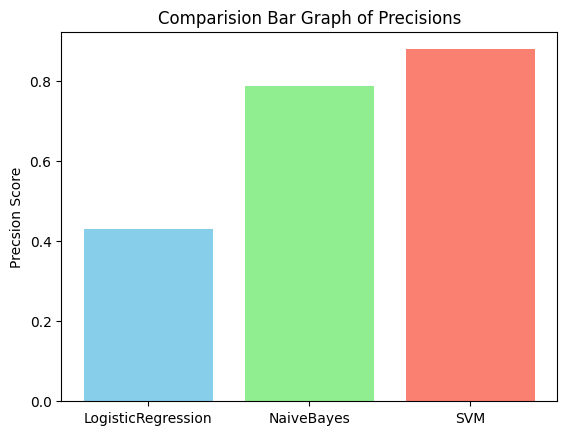

In [55]:
models=['LogisticRegression', 'NaiveBayes', 'SVM']
precisions=[lo_precision, nb_precision, svm_precision]
plt.bar(models, precisions, color=['skyblue', 'lightgreen', 'salmon'])
plt.title("Comparision Bar Graph of Precisions")
plt.ylabel("Precsion Score")
plt.show()

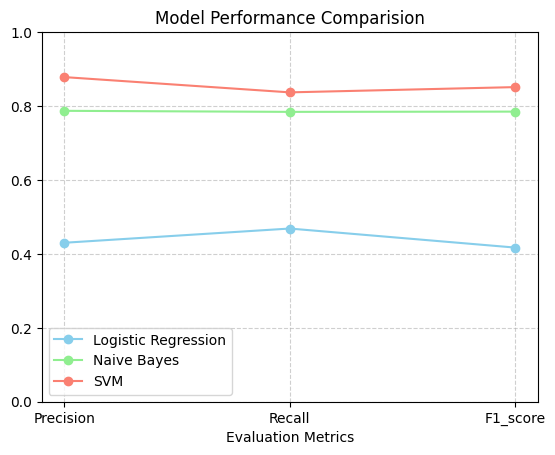

In [56]:
metrics=['Precision', 'Recall', 'F1_score']
lo=[lo_precision, lo_recall, lo_f1]
nb=[nb_precision, nb_recall, nb_f1]
svm=[svm_precision, svm_recall, svm_f1]


plt.plot(metrics, lo, marker='o', color='skyblue', label='Logistic Regression')
plt.plot(metrics, nb, marker='o', color='lightgreen', label='Naive Bayes')
plt.plot(metrics, svm, marker='o', color='salmon', label='SVM')

plt.title("Model Performance Comparision")
plt.xlabel('Evaluation Metrics')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

